In [1]:
# Importing libraries
import os
import sys
import numpy                   as np
import pandas                  as pd
import seaborn                 as sns
import matplotlib              as mpl
import matplotlib.pyplot       as plt
import statsmodels.api         as sm
import statsmodels.formula.api as smf
from   scipy                   import stats
from   scipy.stats             import norm
from   copy                    import deepcopy
from   sklearn.impute          import KNNImputer, SimpleImputer
from   sklearn.preprocessing   import StandardScaler
from   sklearn.pipeline        import Pipeline
from   nilearn.image           import load_img, resample_to_img, coord_transform, new_img_like
from   nilearn.glm             import threshold_stats_img
from   nilearn                 import plotting, datasets
# Importing custom libraries
sys.path.append("..")
from scripts.util     import *
from scripts.subjects import Subject

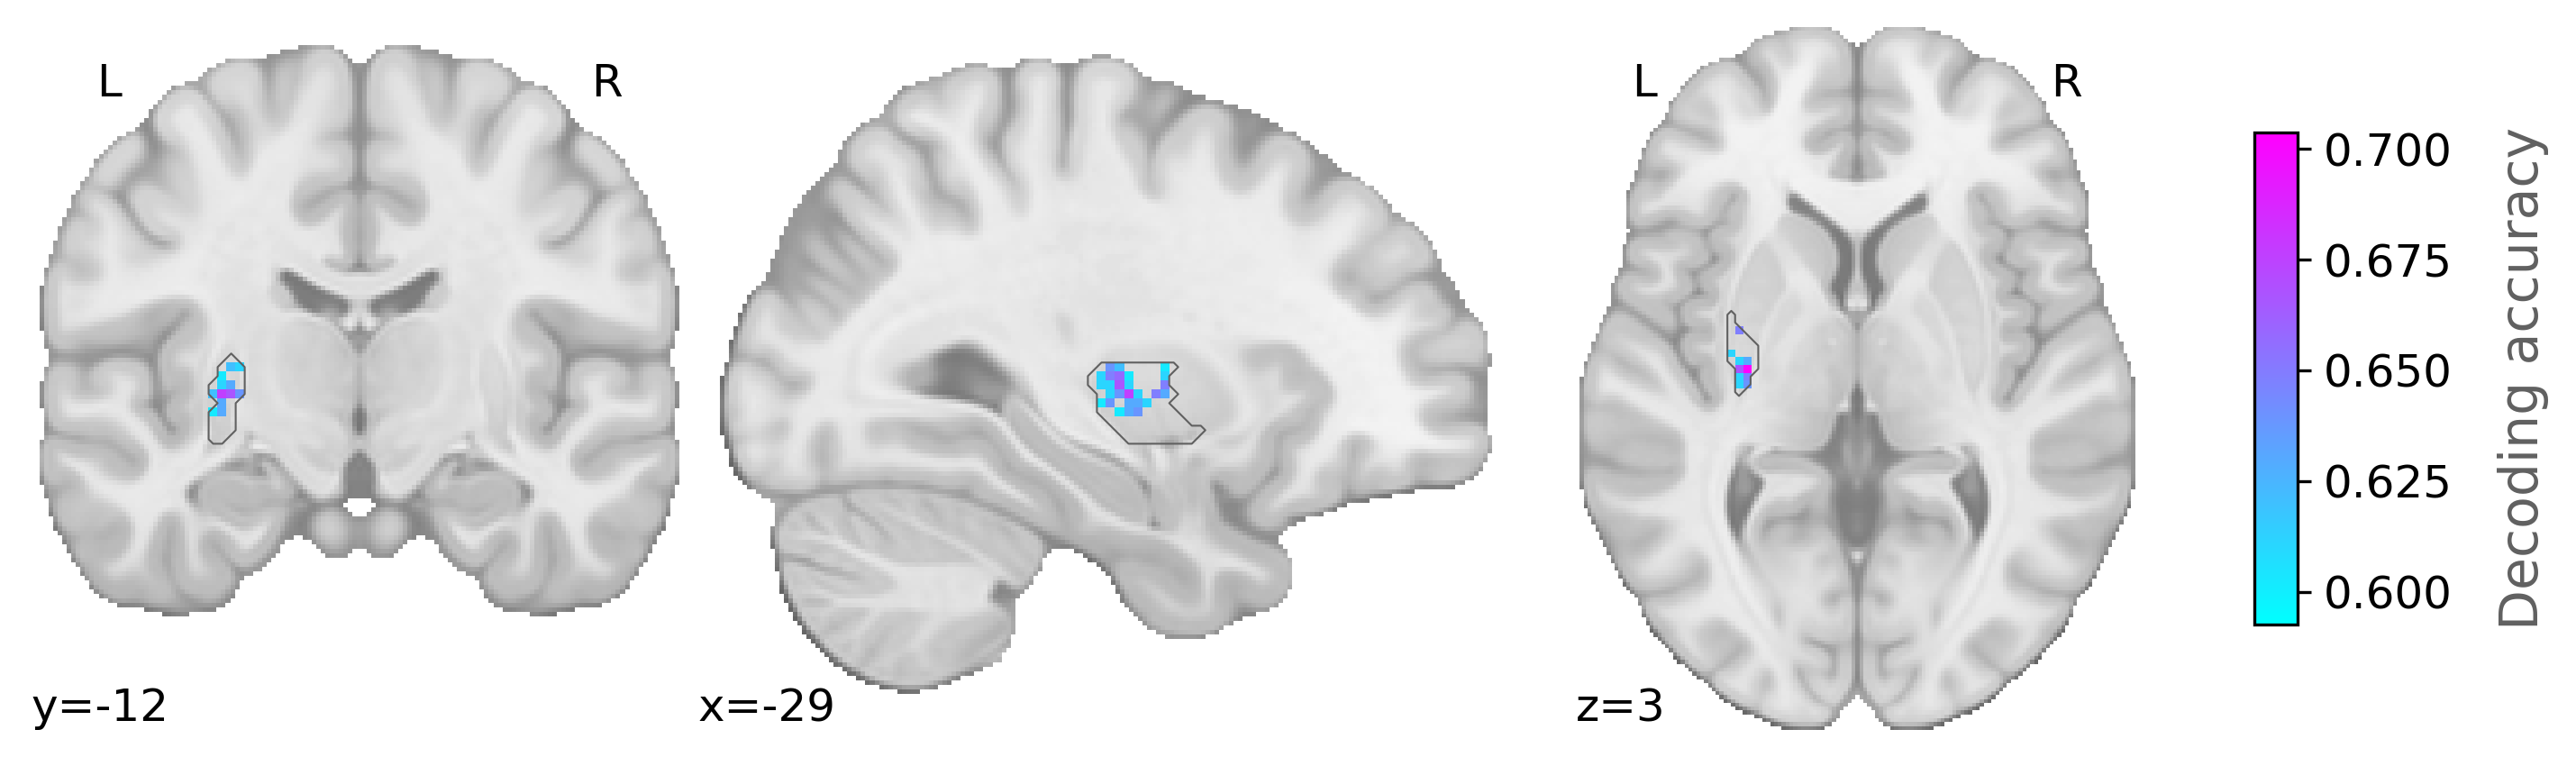

In [3]:
def plot_fig3_panel_a_accuracy_map(
    *,
    RESULTS_DIRECTORY: str,
    FIGURES_DIRECTORY: str,
    acc_relpath: str = os.path.join("mvpa_fwer_clusters", "cluster_left_posterior_putamen_acc.nii"),
    roi_relpath: str = os.path.join("rois", "left_posterior_putamen.nii"),
    outname: str = "figure-3_panel-A.png",
) -> plt.Figure:
    acc_img = load_img(os.path.join(RESULTS_DIRECTORY, acc_relpath))
    roi     = load_img(os.path.join(RESULTS_DIRECTORY, roi_relpath))

    acc_data = acc_img.get_fdata()
    acc_vals = acc_data[acc_data != 0]
    vmin     = acc_vals.min()
    vmax     = acc_vals.max()

    data = acc_data.copy()
    mask = data != 0
    data[mask] = data[mask] - vmin
    acc_img = new_img_like(acc_img, data)

    cmap = plt.get_cmap("cool")
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    ANNOT_FONT_SIZE = 9
    ANNOT_COLOR     = "#606060"

    fig = plt.figure(figsize=(8.0, 2.6), dpi=300)

    with mpl.rc_context({"font.size": ANNOT_FONT_SIZE, "text.color": ANNOT_COLOR}):
        display = plotting.plot_stat_map(
            acc_img,
            figure=fig,
            bg_img=datasets.load_mni152_template(),
            cmap="cool",
            colorbar=False,
            black_bg=False,
            annotate=True,
            draw_cross=False,
            title="",
        )

    display.add_contours(
        roi,
        levels=[0.5],
        linewidths=0.5,
        colors="#606060",
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cax = fig.add_axes([1.03, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.ax.yaxis.set_label_position("right")
    cbar.set_label("Decoding accuracy", fontsize=14, color="#606060", labelpad=12)
    cbar.ax.tick_params(labelsize=12)

    outpath = os.path.join(FIGURES_DIRECTORY, outname)
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    fig.savefig(outpath, bbox_inches="tight", dpi=300)

    return fig


# Example usage:
fig = plot_fig3_panel_a_accuracy_map(
    RESULTS_DIRECTORY=RESULTS_DIRECTORY,
    FIGURES_DIRECTORY=FIGURES_DIRECTORY,
)

Number of voxels in left posterior putamen cluster: 60


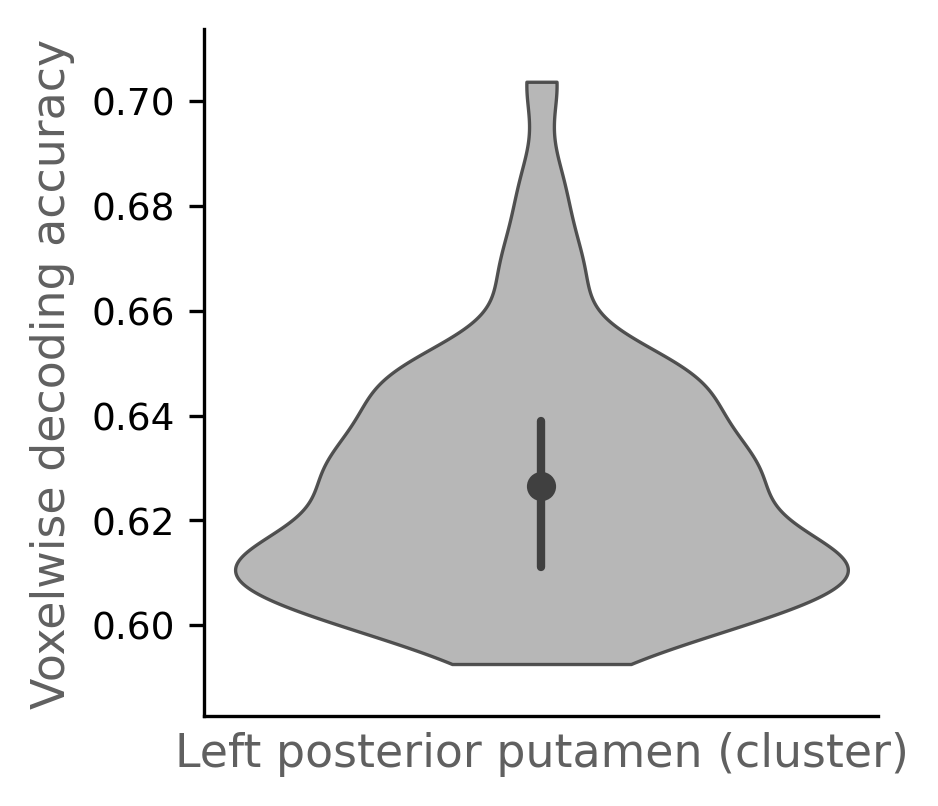

In [4]:
def plot_fig3_panel_b_violin(
    *,
    RESULTS_DIRECTORY: str,
    FIGURES_DIRECTORY: str,
    acc_relpath: str = os.path.join("mvpa_fwer_clusters", "cluster_left_posterior_putamen_acc.nii"),
    outname: str = "figure-3_panel-B.png",
) -> tuple[plt.Figure, plt.Axes]:
    acc_img = load_img(os.path.join(RESULTS_DIRECTORY, acc_relpath))
    data = acc_img.get_fdata()
    data = data[data != 0].ravel()

    print(f"Number of voxels in left posterior putamen cluster: {data.shape[0]}")

    fig, ax = plt.subplots(figsize=(3.0, 2.6), dpi=300)

    AXIS_LABEL_COLOR = "#606060"

    VIOLIN_BW = 0.3
    kde = stats.gaussian_kde(data, bw_method=VIOLIN_BW)

    y = np.linspace(data.min(), data.max(), 800)
    density = kde(y)

    max_width = 0.35
    density_scaled = (density / density.max()) * max_width

    pos = 0
    ax.fill_betweenx(
        y,
        pos - density_scaled,
        pos + density_scaled,
        facecolor="#B0B0B0",
        edgecolor="#404040",
        linewidth=0.8,
        alpha=0.9,
        zorder=2,
    )

    p25, p75 = np.percentile(data, [25, 75])
    mean = np.mean(data)

    ax.plot(
        [pos, pos],
        [p25, p75],
        color="#404040",
        lw=2.0,
        solid_capstyle="round",
        zorder=3,
    )

    ax.scatter(
        [pos],
        [mean],
        s=36,
        color="#404040",
        zorder=4,
    )

    ax.set_xticks([pos])
    ax.set_xticklabels(["Left posterior putamen (cluster)"], fontsize=11, color=AXIS_LABEL_COLOR)
    ax.set_ylabel("Voxelwise decoding accuracy", fontsize=11, color=AXIS_LABEL_COLOR)

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", length=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    pad = 0.01
    ax.set_ylim(data.min() - pad, data.max() + pad)

    plt.tight_layout(pad=0.4)

    outpath = os.path.join(FIGURES_DIRECTORY, outname)
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    fig.savefig(outpath, bbox_inches="tight", dpi=300)

    return fig, ax


# Example usage:
fig, ax = plot_fig3_panel_b_violin(
    RESULTS_DIRECTORY=RESULTS_DIRECTORY,
    FIGURES_DIRECTORY=FIGURES_DIRECTORY,
)

(100,) (5000,)
0.5823232489882955


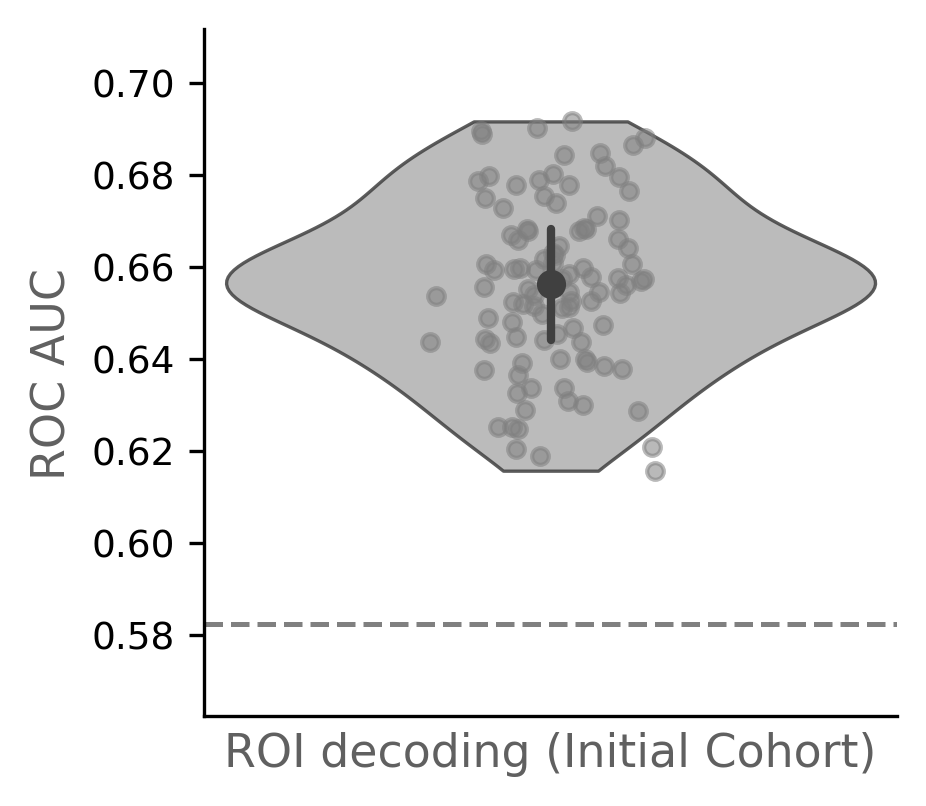

In [ ]:
def plot_fig3_panel_c_roi_decoding(
    *,
    RESULTS_DIRECTORY: str,
    FIGURES_DIRECTORY: str,
    score_relpath: str = os.path.join("roi_decoding", "initial_cohort-scores.npy"),
    perm_relpath: str  = os.path.join("roi_decoding", "initial_cohort-perm_scores.npy"),
    outname: str = "figure-3_panel-C.png",
) -> tuple[plt.Figure, plt.Axes]:
    score = np.load(os.path.join(RESULTS_DIRECTORY, score_relpath)).ravel()
    perm  = np.load(os.path.join(RESULTS_DIRECTORY, perm_relpath)).ravel()

    print(score.shape, perm.shape)

    mean_score = score.mean()
    sem_score  = score.std(ddof=1) / np.sqrt(len(score))

    null_95 = np.percentile(perm, 95)
    print(null_95)

    fig, ax = plt.subplots(figsize=(3.0, 2.6), dpi=300)
    pos = 0

    parts = ax.violinplot(
        score,
        positions=[pos],
        widths=0.75,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor("#B0B0B0")
        pc.set_edgecolor("#404040")
        pc.set_linewidth(0.8)
        pc.set_alpha(0.85)

    rng = np.random.default_rng(0)
    x = rng.normal(0, 0.06, size=len(score))
    ax.scatter(x, score, s=16, color="#808080", alpha=0.55, zorder=2)

    p25, p75 = np.percentile(score, [25, 75])
    mean = np.mean(score)

    ax.plot(
        [pos, pos],
        [p25, p75],
        color="#404040",
        lw=2.0,
        solid_capstyle="round",
        zorder=3,
    )

    ax.scatter(
        [pos],
        [mean],
        s=36,
        color="#404040",
        zorder=4,
    )

    ax.axhline(
        null_95,
        color="#808080",
        linestyle="--",
        linewidth=1.2,
        zorder=1,
    )

    ax.set_xlim(-0.4, 0.4)
    ax.set_xticks([pos])
    ax.set_xticklabels(
        ["ROI decoding (Initial Cohort)"],
        fontsize=11,
        color="#606060",
    )

    ax.set_ylabel("ROC AUC", fontsize=11, color="#606060")
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", length=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ymin = min(score.min(), null_95) - 0.02
    ymax = max(score.max(), null_95) + 0.02
    ax.set_ylim(ymin, ymax)

    plt.tight_layout(pad=0.4)

    outpath = os.path.join(FIGURES_DIRECTORY, outname)
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    fig.savefig(outpath, bbox_inches="tight", dpi=300)

    return fig, ax


# Example usage:
fig, ax = plot_fig3_panel_c_roi_decoding(
    RESULTS_DIRECTORY=RESULTS_DIRECTORY,
    FIGURES_DIRECTORY=FIGURES_DIRECTORY,
)